# Visualise all results


## Import modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load results.csv

In [2]:
# Load all results
results_lr  = pd.read_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_lr.csv')
results_rf  = pd.read_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_rf.csv')
results_xgb = pd.read_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_xg.csv')
results_nn  = pd.read_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_nn.csv')

# Add model names
results_lr['Model']  = 'Logistic Regression'
results_rf['Model']  = 'Random Forest'
results_xgb['Model'] = 'XGBoost'
results_nn['Model']  = 'Neural Network'

# Combine
results = pd.concat([results_lr, results_rf, results_xgb, results_nn],
                         ignore_index=True)

In [3]:
results

,Outcome,Platform,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Samples,Model
0,Death From Disease,RNASEQ,0.816327,0.533333,0.800000,0.640000,0.876923,243,Logistic Regression
1,Death From Disease,MICROARRAY,0.840000,0.583333,0.700000,0.636364,0.882500,246,Logistic Regression
2,High Risk,RNASEQ,0.959184,1.000000,0.875000,0.933333,0.994318,243,Logistic Regression
3,High Risk,MICROARRAY,0.960000,1.000000,0.882353,0.937500,0.989305,246,Logistic Regression
4,Progression,RNASEQ,0.734694,0.631579,0.666667,0.648649,0.797491,243,Logistic Regression
5,Progression,MICROARRAY,0.720000,0.600000,0.666667,0.631579,0.730903,246,Logistic Regression
6,Death From Disease,RNASEQ,0.775510,0.470588,0.800000,0.592593,0.851282,243,Random Forest
7,Death From Disease,MICROARRAY,0.860000,0.666667,0.600000,0.631579,0.895000,246,Random Forest
8,High Risk,RNASEQ,0.938776,0.882353,0.937500,0.909091,0.984848,243,Random Forest
9,High Risk,MICROARRAY,0.940000,0.937500,0.882353,0.909091,0.992870,246,Random Forest


## Plot ROC-AUC heatmap

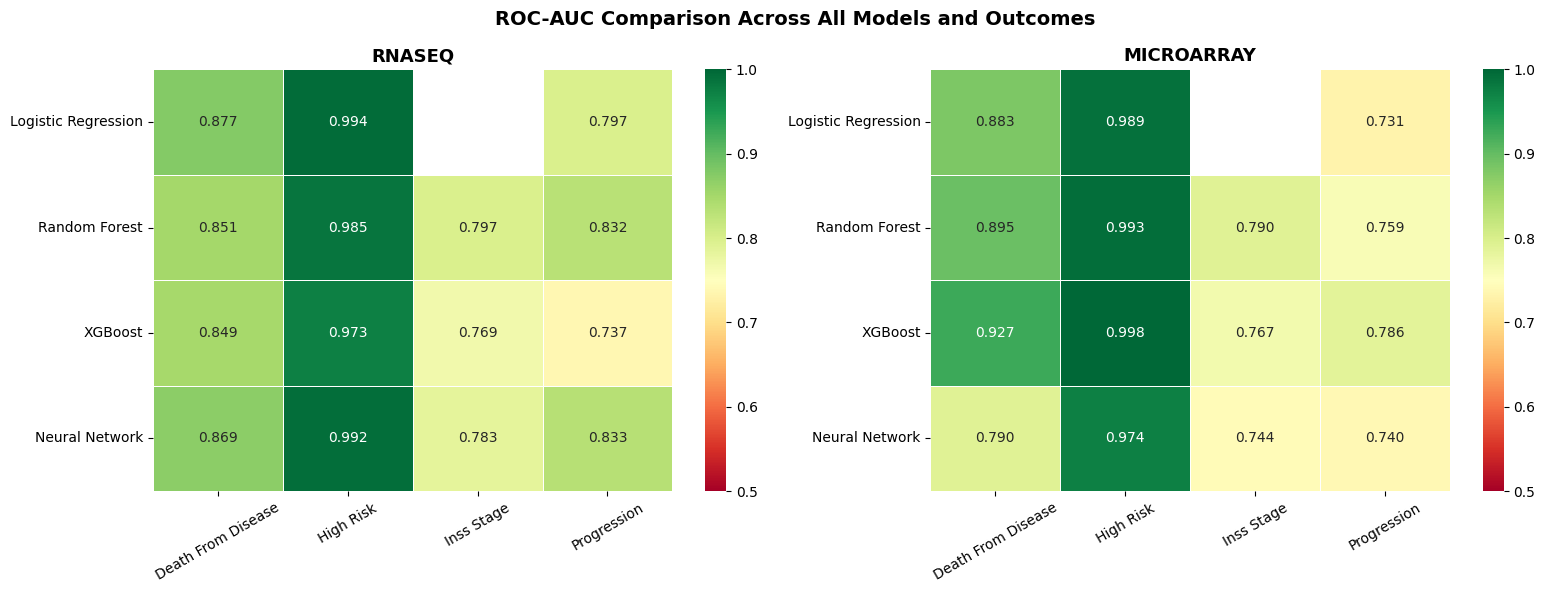

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

platforms = ['RNASEQ', 'MICROARRAY']

for idx, platform in enumerate(platforms):
    ax = axes[idx]

    platform_data = results[results['Platform'] == platform]

    heatmap_data = platform_data.pivot_table(
        values='ROC-AUC',
        index='Model',
        columns='Outcome'
    )

    # Reorder models
    model_order = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']
    heatmap_data = heatmap_data.reindex(model_order)

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0.5,
        vmax=1.0,
        ax=ax,
        linewidths=0.5,
        annot_kws={'size': 10}
    )
    ax.set_title(f'{platform}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('ROC-AUC Comparison Across All Models and Outcomes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Plot grouped bar chart per outcome

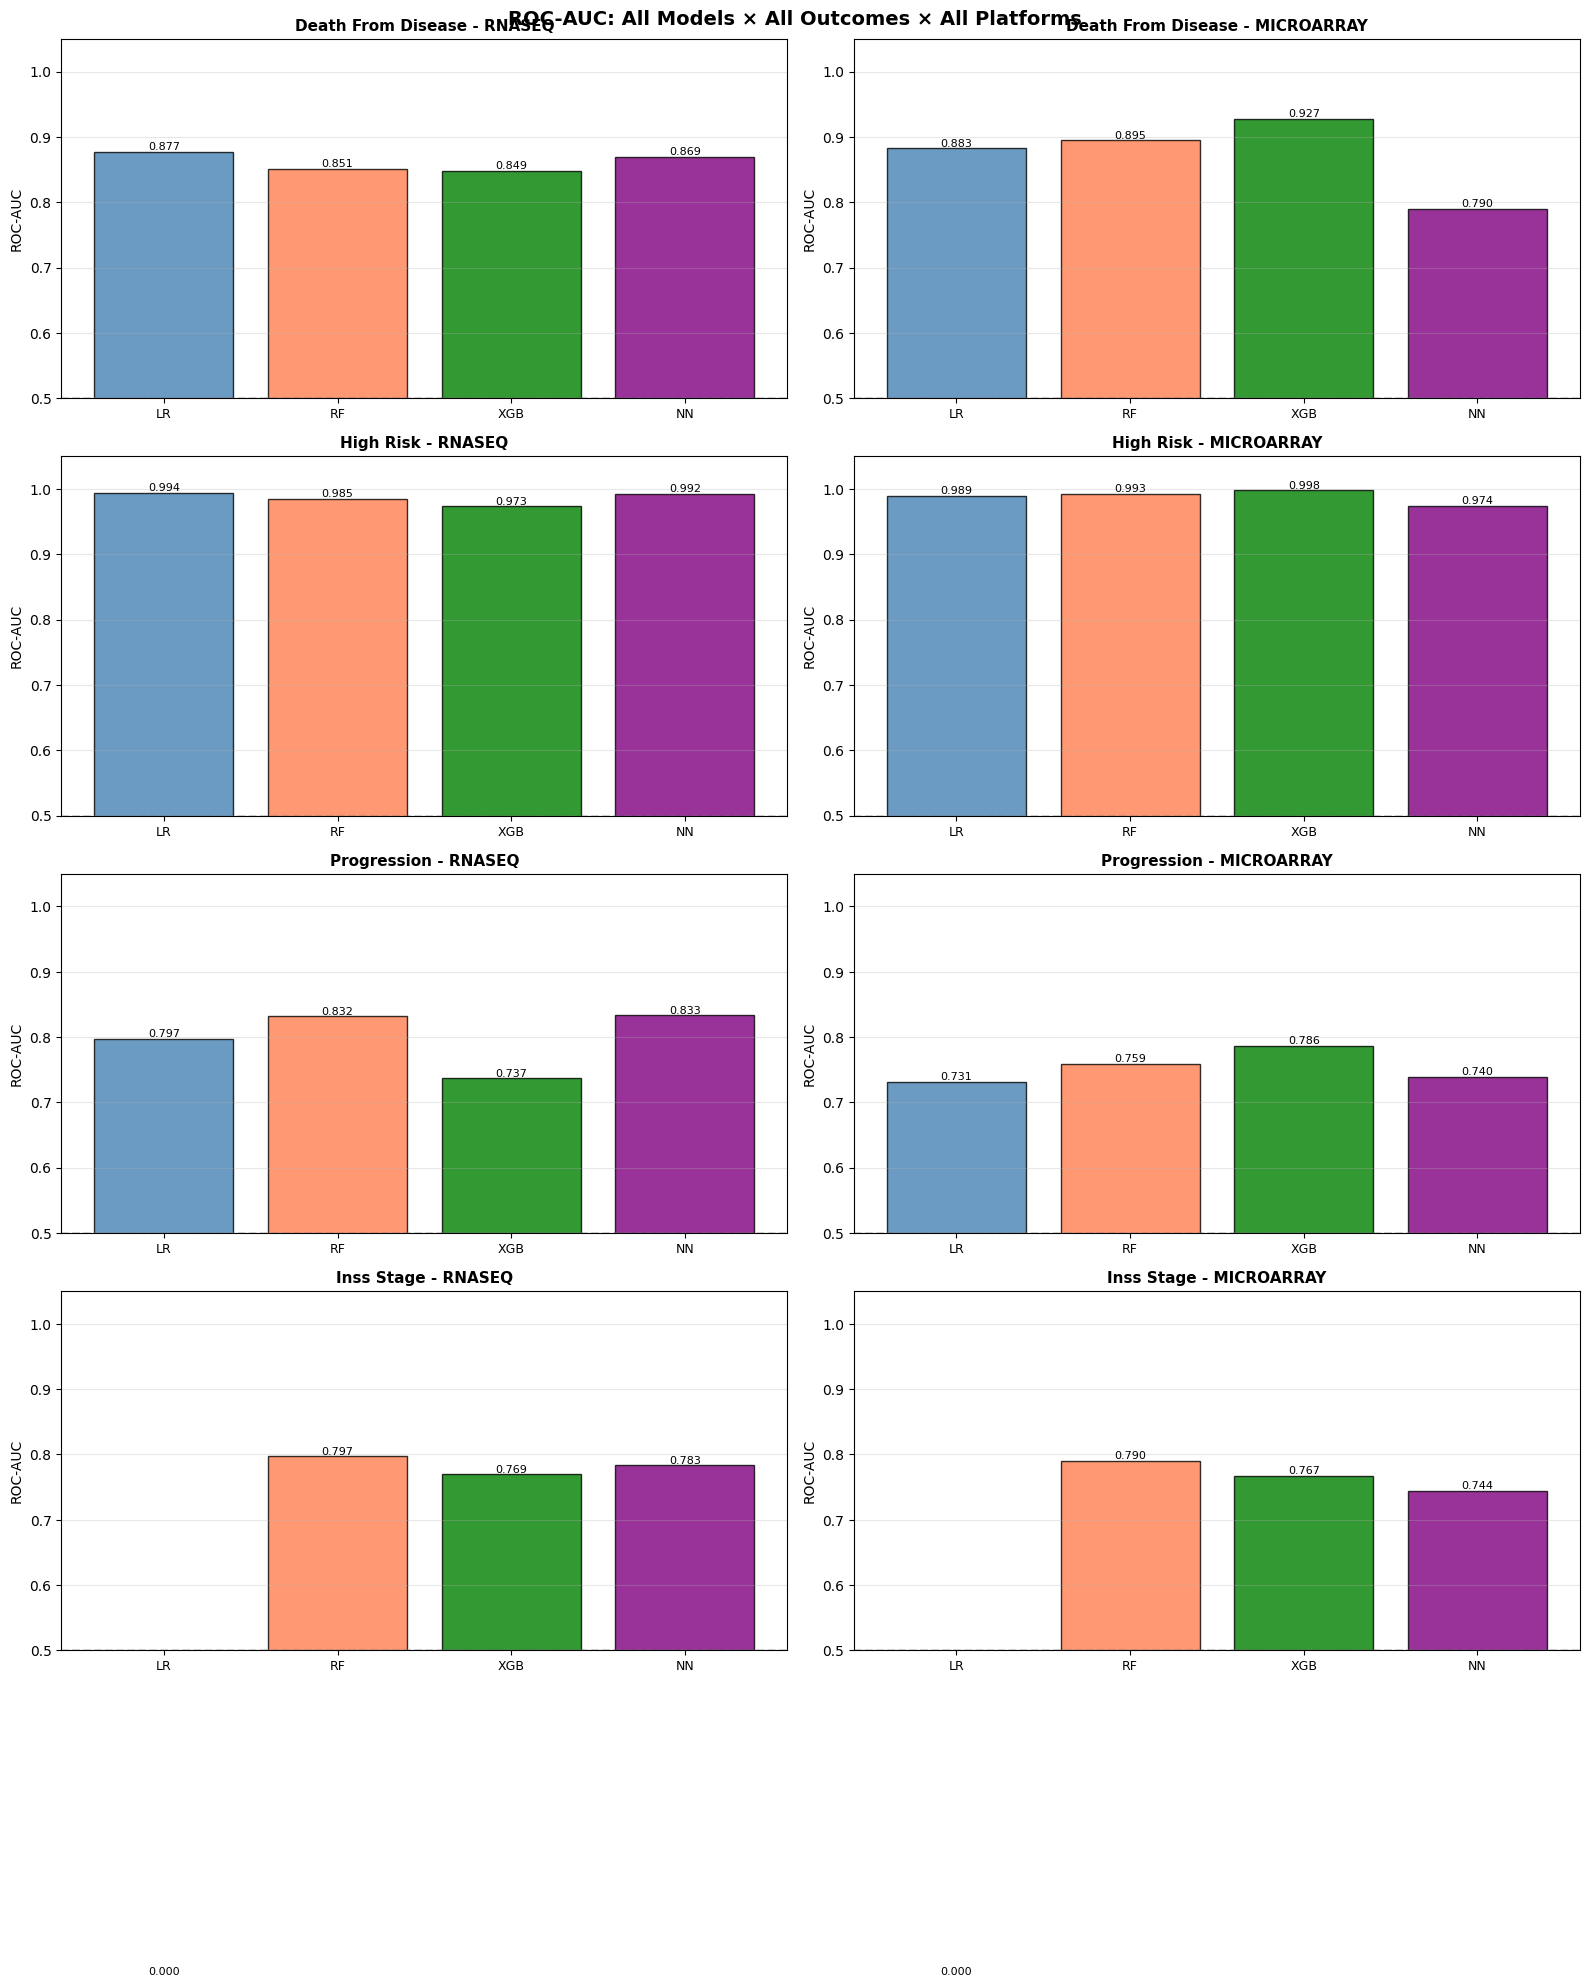

In [5]:
outcomes = results['Outcome'].unique()
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']
colors = ['steelblue', 'coral', 'green', 'purple']
platforms = ['RNASEQ', 'MICROARRAY']

fig, axes = plt.subplots(len(outcomes), 2, figsize=(16, 20))

for row_idx, outcome in enumerate(outcomes):
    for col_idx, platform in enumerate(platforms):
        ax = axes[row_idx][col_idx]

        mask = (results['Outcome'] == outcome) & (results['Platform'] == platform)
        outcome_data = results[mask]

        x = np.arange(len(models))
        values = [outcome_data[outcome_data['Model'] == m]['ROC-AUC'].values[0]
                  if len(outcome_data[outcome_data['Model'] == m]) > 0 else 0
                  for m in models]

        bars = ax.bar(x, values, color=colors, alpha=0.8, edgecolor='black')

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(['LR', 'RF', 'XGB', 'NN'], fontsize=9)
        ax.set_ylim([0.5, 1.05])
        ax.set_ylabel('ROC-AUC', fontsize=10)
        ax.set_title(f'{outcome} - {platform}', fontsize=11, fontweight='bold')
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('ROC-AUC: All Models × All Outcomes × All Platforms',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Generate markdown table

In [6]:
# Pivot to get best model per outcome/platform
def generate_readme_table(results, metric='ROC-AUC'):

    lines = []

    for platform in ['RNASEQ', 'MICROARRAY']:
        lines.append(f'\n### {platform}\n')
        lines.append(f'| Outcome | Logistic Regression | Random Forest | XGBoost | Neural Network | **Best** |')
        lines.append(f'|---------|--------------------:|-------------:|--------:|---------------:|----------|')

        platform_data = results[results['Platform'] == platform]

        for outcome in ['Death From Disease', 'High Risk', 'Progression', 'Inss Stage']:
            outcome_data = platform_data[platform_data['Outcome'] == outcome]

            values = {}
            for model in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']:
                row = outcome_data[outcome_data['Model'] == model]
                values[model] = row[metric].values[0] if len(row) > 0 else None

            best_model = max(values, key=lambda k: values[k] if values[k] is not None else 0)

            row_str = f'| {outcome} '
            for model in ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network']:
                v = values[model]
                val_str = f'{v:.3f}' if v is not None else 'N/A'
                # Bold the best value
                if model == best_model:
                    row_str += f'| **{val_str}** '
                else:
                    row_str += f'| {val_str} '
            row_str += f'| **{best_model}** |'
            lines.append(row_str)

    return '\n'.join(lines)

# Generate and print table
table = generate_readme_table(results, metric='ROC-AUC')
print(table)

# Save to file
# with open('/content/drive/MyDrive/readme_table.md', 'w') as f:
#     f.write('## Model Performance Comparison (ROC-AUC)\n')
#     f.write(table)

# print("\nTable saved to readme_table.md")


### RNASEQ

| Outcome | Logistic Regression | Random Forest | XGBoost | Neural Network | **Best** |
|---------|--------------------:|-------------:|--------:|---------------:|----------|
| Death From Disease | **0.877** | 0.851 | 0.849 | 0.869 | **Logistic Regression** |
| High Risk | **0.994** | 0.985 | 0.973 | 0.992 | **Logistic Regression** |
| Progression | 0.797 | 0.832 | 0.737 | **0.833** | **Neural Network** |
| Inss Stage | N/A | **0.797** | 0.769 | 0.783 | **Random Forest** |

### MICROARRAY

| Outcome | Logistic Regression | Random Forest | XGBoost | Neural Network | **Best** |
|---------|--------------------:|-------------:|--------:|---------------:|----------|
| Death From Disease | 0.883 | 0.895 | **0.927** | 0.790 | **XGBoost** |
| High Risk | 0.989 | 0.993 | **0.998** | 0.974 | **XGBoost** |
| Progression | 0.731 | 0.759 | **0.786** | 0.740 | **XGBoost** |
| Inss Stage | N/A | **0.790** | 0.767 | 0.744 | **Random Forest** |



### RNA-Seq

| Outcome | Logistic Regression | Random Forest | XGBoost | Neural Network | **Best** |
|---------|--------------------:|-------------:|--------:|---------------:|----------|
| Death From Disease | **0.877** | 0.851 | 0.849 | 0.869 | **Logistic Regression** |
| High Risk | **0.994** | 0.985 | 0.973 | 0.992 | **Logistic Regression** |
| Progression | 0.797 | 0.832 | 0.737 | **0.833** | **Neural Network** |
| Inss Stage | N/A | **0.797** | 0.769 | 0.783 | **Random Forest** |

### Microarray

| Outcome | Logistic Regression | Random Forest | XGBoost | Neural Network | **Best** |
|---------|--------------------:|-------------:|--------:|---------------:|----------|
| Death From Disease | 0.883 | 0.895 | **0.927** | 0.790 | **XGBoost** |
| High Risk | 0.989 | 0.993 | **0.998** | 0.974 | **XGBoost** |
| Progression | 0.731 | 0.759 | **0.786** | 0.740 | **XGBoost** |
| Inss Stage | N/A | **0.790** | 0.767 | 0.744 | **Random Forest** |
